# Gráficas para `eda_report_20260421.md`

Este notebook recrea las principales vistas descriptivas de [`reports/eda/eda_report_20260421.md`](reports/eda/eda_report_20260421.md) directamente desde el dataset en parquet usando `matplotlib` y `seaborn`.

Se enfoca en las secciones del reporte más adecuadas para graficar:
- calidad de datos
- distribución política
- geografía
- educación
- edad
- experiencia previa
- trayectorias por legislatura
- comisiones
- correlaciones simples


In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid', context='talk', palette='deep')
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['legend.frameon'] = False


In [4]:
DATA_PATH = Path('data/database/clean/diputados_20260421_205712.parquet')
REPORT_PATH = Path('reports/eda/sqleda_20260421_205712.md')

if not DATA_PATH.exists():
    raise FileNotFoundError(f'Archivo parquet no encontrado: {DATA_PATH}')
if not REPORT_PATH.exists():
    raise FileNotFoundError(f'Archivo de reporte no encontrado: {REPORT_PATH}')

df = pd.read_parquet(DATA_PATH).copy()
print(f'Fuente de datos: {DATA_PATH}')
print(f'Fuente de reporte: {REPORT_PATH}')
print(f'Dimensión: {df.shape[0]:,} filas x {df.shape[1]:,} columns')


Fuente de datos: data/database/clean/diputados_20260421_205712.parquet
Fuente de reporte: reports/eda/sqleda_20260421_205712.md
Dimensión: 5,000 filas x 78 columns


In [5]:
roman_map = {
    57: 'LVII', 58: 'LVIII', 59: 'LIX', 60: 'LX', 61: 'LXI',
    62: 'LXII', 63: 'LXIII', 64: 'LXIV', 65: 'LXV', 66: 'LXVI'
}

def add_roman_legislature(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    out['legislatura_roman'] = out['legislatura_num'].map(roman_map)
    return out

plot_df = add_roman_legislature(df)
plot_df.head()


,diputado_id,referencia,legislatura_nombre,legislatura_num,partido_nombre,nombre,partido,suplente_referencia,en_licencia,y_nacimiento,...,acad_uv,n_trayectoria_legislativa,n_trayectoria_politica,n_trayectoria_empresarial,n_investigacion_docencia,n_organos_gobierno,source_file,partido_mayoria,es_partido_mayoria,legislatura_roman
0,1c230671710f,569096,LIX,59,Partido Revolucionario Institucional,Abel Echeverría Pineda,PRI,2178850,False,1954.0,...,0,1,6,0,0,0,LIX_20260421_203103.csv,PRI,1,LIX
1,f2e201f17d25,569639,LIX,59,Partido Revolucionario Institucional,Juan Manuel Vega Rayet,PRI,2178954,False,1959.0,...,0,1,11,6,0,0,LIX_20260421_203103.csv,PRI,1,LIX
2,f6992bc28127,570142,LIX,59,Partido Revolucionario Institucional,Homero Díaz Rodríguez,PRI,1605914,False,1959.0,...,0,1,8,4,0,0,LIX_20260421_203103.csv,PRI,1,LIX
3,88d43431e385,569457,LIX,59,Partido Revolucionario Institucional,Humberto Cervantes Vega,PRI,2177754,False,1944.0,...,0,2,14,0,0,0,LIX_20260421_203103.csv,PRI,1,LIX
4,44f9ad0663da,569215,LIX,59,Partido Revolucionario Institucional,César Amín González Orantes,PRI,2178870,False,1961.0,...,0,0,10,2,0,0,LIX_20260421_203103.csv,PRI,1,LIX


## 1. Calidad de datos

,variable,nulos,pct
10,edad_al_tomar_cargo,510,10.20
9,y_nacimiento,506,10.12
20,distrito_circ,211,4.22


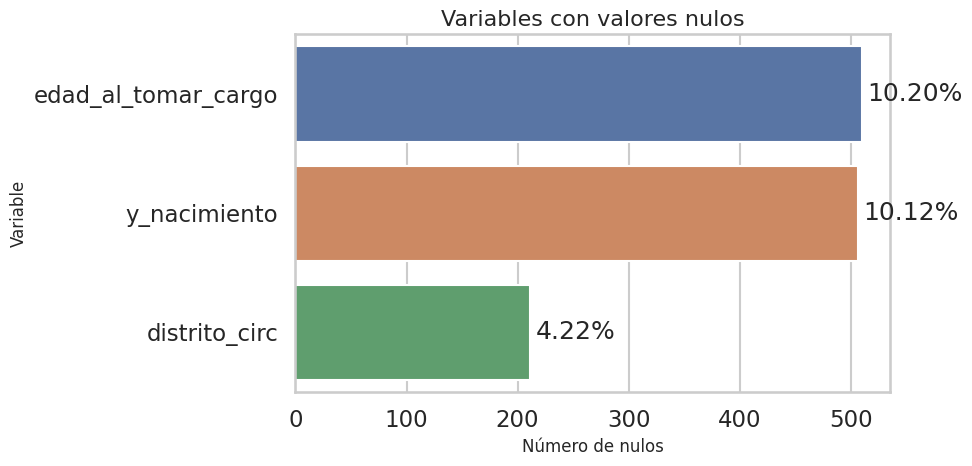

In [6]:
missing = (
    df.isna()
    .sum()
    .rename('nulos')
    .reset_index()
    .rename(columns={'index': 'variable'})
)
missing['pct'] = 100 * missing['nulos'] / len(df)
missing = missing[missing['nulos'] > 0].sort_values('nulos', ascending=False)

display(missing)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=missing, x='nulos', y='variable', hue='variable', dodge=False, ax=ax, legend=False)
ax.set_title('Variables con valores nulos')
ax.set_xlabel('Número de nulos')
ax.set_ylabel('Variable')
for i, row in missing.reset_index(drop=True).iterrows():
    ax.text(row['nulos'] + 5, i, f"{row['pct']:.2f}%", va='center')
plt.tight_layout()
plt.show()


## 2. Distribución política

,partido_nombre,n,pct
0,Partido Revolucionario Institucional,1564,31.28
1,Partido Acción Nacional,1298,25.96
2,Morena,768,15.36
3,Partido de la Revolución Democrática,634,12.68
4,Partido Verde Ecologista de México,255,5.10
5,Partido del Trabajo,189,3.78
6,Movimiento Ciudadano,120,2.40
7,Independiente,47,0.94
8,Partido Nueva Alianza,40,0.80
9,Encuentro Social,34,0.68


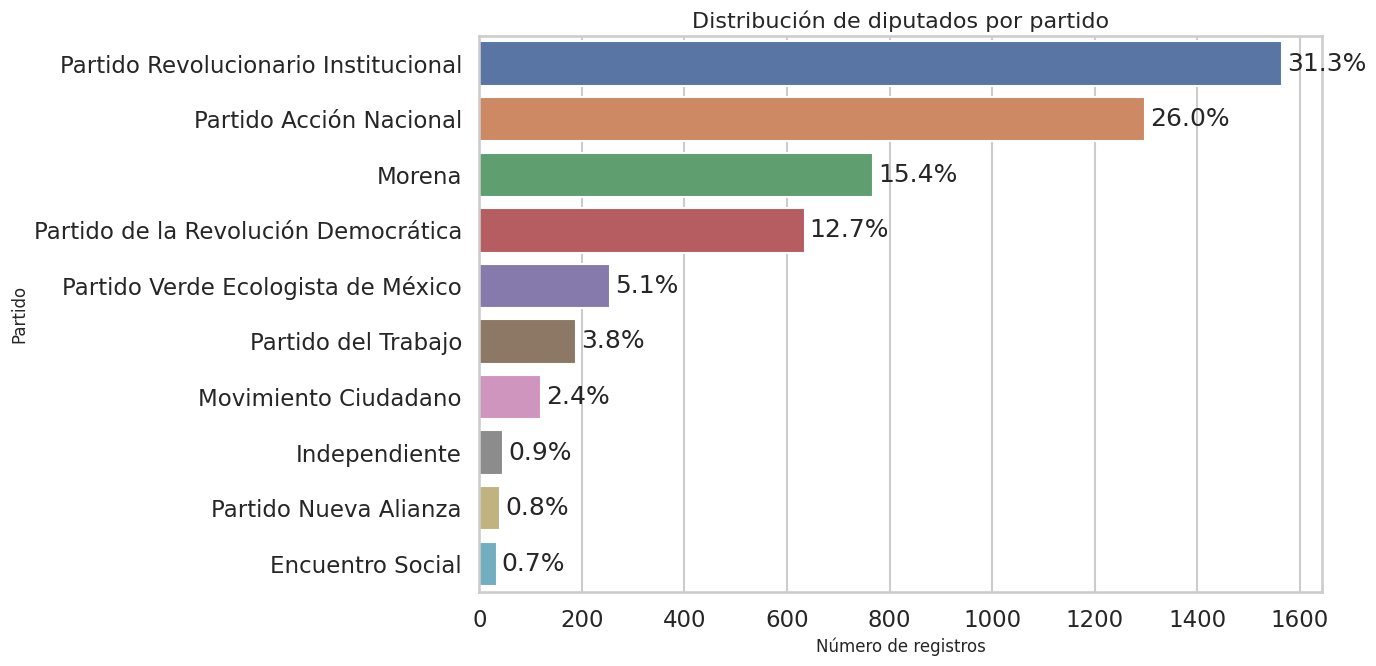

In [7]:
party_counts = (
    df['partido_nombre']
    .fillna('Desconocido')
    .value_counts()
    .rename_axis('partido_nombre')
    .reset_index(name='n')
)
party_counts['pct'] = 100 * party_counts['n'] / len(df)
party_top = party_counts.head(10)

display(party_top)

fig, ax = plt.subplots(figsize=(14, 7))
sns.barplot(data=party_top, x='n', y='partido_nombre', hue='partido_nombre', dodge=False, ax=ax, legend=False)
ax.set_title('Distribución de diputados por partido')
ax.set_xlabel('Número de registros')
ax.set_ylabel('Partido')
for i, row in party_top.reset_index(drop=True).iterrows():
    ax.text(row['n'] + 10, i, f"{row['pct']:.1f}%", va='center')
plt.tight_layout()
plt.show()


## 3. Geografía

,entidad_codigo,n
0,MEX,597
1,CDMX,503
2,VER,311
3,JAL,284
4,DESCONOCIDO,211
5,PUE,196
6,NL,196
7,GTO,195
8,MICH,193
9,CHIS,179


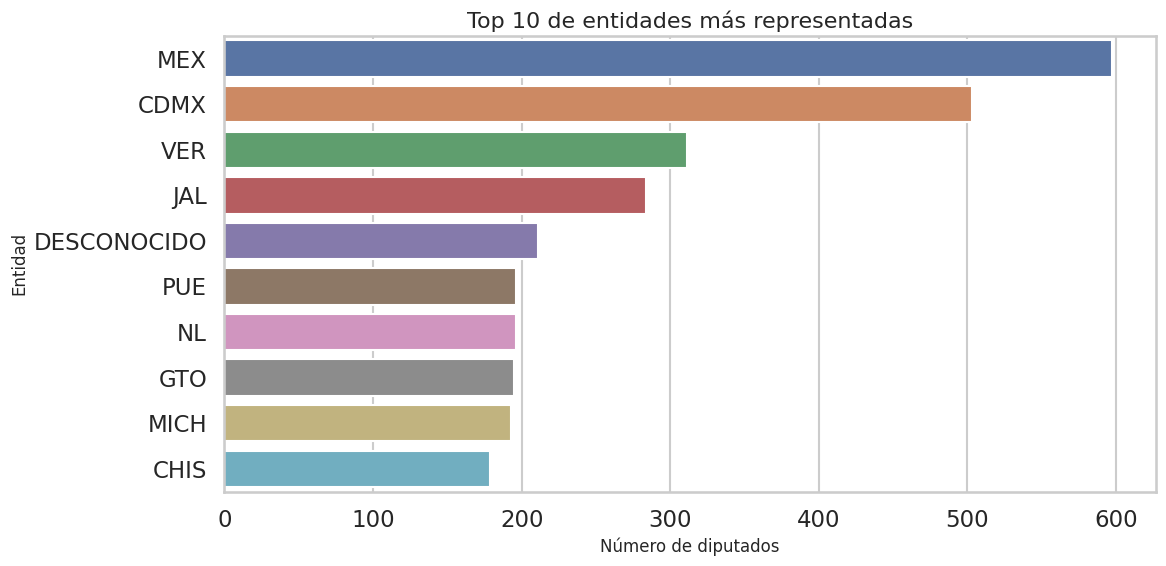

In [8]:
entity_counts = (
    df['entidad_codigo']
    .fillna('DESCONOCIDO')
    .value_counts()
    .rename_axis('entidad_codigo')
    .reset_index(name='n')
)
entity_top = entity_counts.head(10)

display(entity_top)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=entity_top, x='n', y='entidad_codigo', hue='entidad_codigo', dodge=False, ax=ax, legend=False)
ax.set_title('Top 10 de entidades más representadas')
ax.set_xlabel('Número de diputados')
ax.set_ylabel('Entidad')
plt.tight_layout()
plt.show()


## 4. Perfil educativo

,grado_estudios_ord,n,etiqueta,pct
0,0,1839,Sin dato,36.78
1,1,62,Primaria,1.24
2,2,128,Secundaria,2.56
3,4,108,Preparatoria,2.16
4,5,324,Lic. incompleta,6.48
5,6,2335,Licenciatura,46.70
6,7,1,Especialidad,0.02
7,9,203,Doctorado,4.06


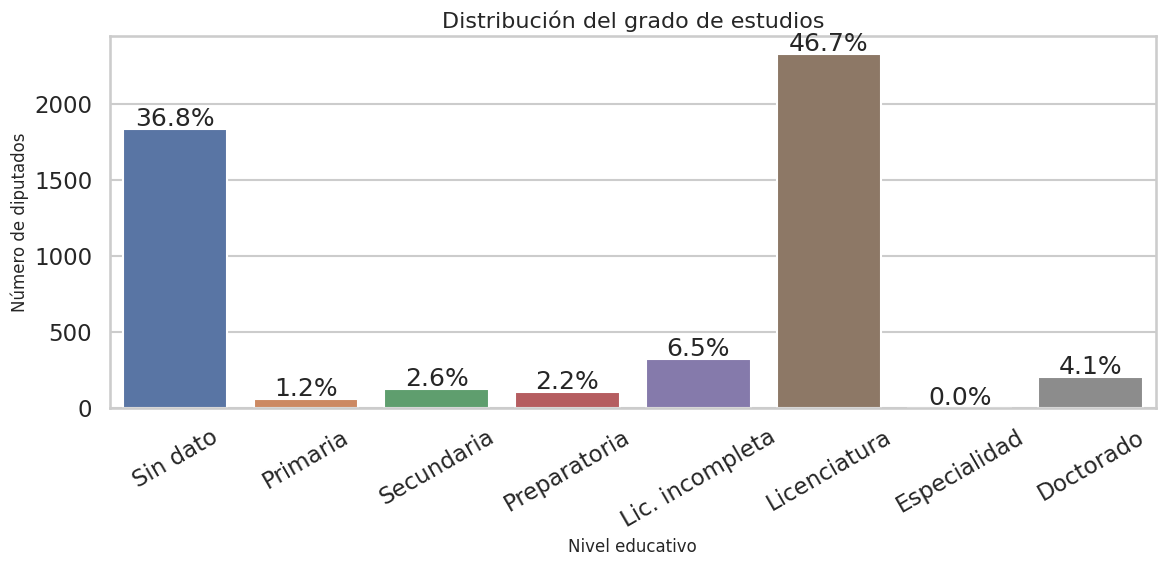

In [9]:
grade_labels = {
    0: 'Sin dato',
    1: 'Primaria',
    2: 'Secundaria',
    4: 'Preparatoria',
    5: 'Lic. incompleta',
    6: 'Licenciatura',
    7: 'Especialidad',
    9: 'Doctorado',
}

grade_dist = (
    df['grado_estudios_ord']
    .fillna(-1)
    .astype(int)
    .value_counts()
    .sort_index()
    .rename_axis('grado_estudios_ord')
    .reset_index(name='n')
)
grade_dist['etiqueta'] = grade_dist['grado_estudios_ord'].map(grade_labels).fillna('Otro')
grade_dist['pct'] = 100 * grade_dist['n'] / len(df)

display(grade_dist)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=grade_dist, x='etiqueta', y='n', hue='etiqueta', dodge=False, ax=ax, legend=False)
ax.set_title('Distribución del grado de estudios')
ax.set_xlabel('Nivel educativo')
ax.set_ylabel('Número de diputados')
ax.tick_params(axis='x', rotation=30)
for i, row in grade_dist.reset_index(drop=True).iterrows():
    ax.text(i, row['n'] + 20, f"{row['pct']:.1f}%", ha='center')
plt.tight_layout()
plt.show()


,area_formacion,n,pct
0,Derecho,1216,24.32
1,Otra,1136,22.72
2,Administración y Contaduría,660,13.20
3,Ciencias Políticas y Sociales,600,12.00
4,Ciencias de la Educación,318,6.36
5,Ingeniería,278,5.56
6,Económico-Financiera,242,4.84
7,Ciencias de la Salud,206,4.12
8,Comunicación,106,2.12
9,Agropecuaria y Zootecnia,77,1.54


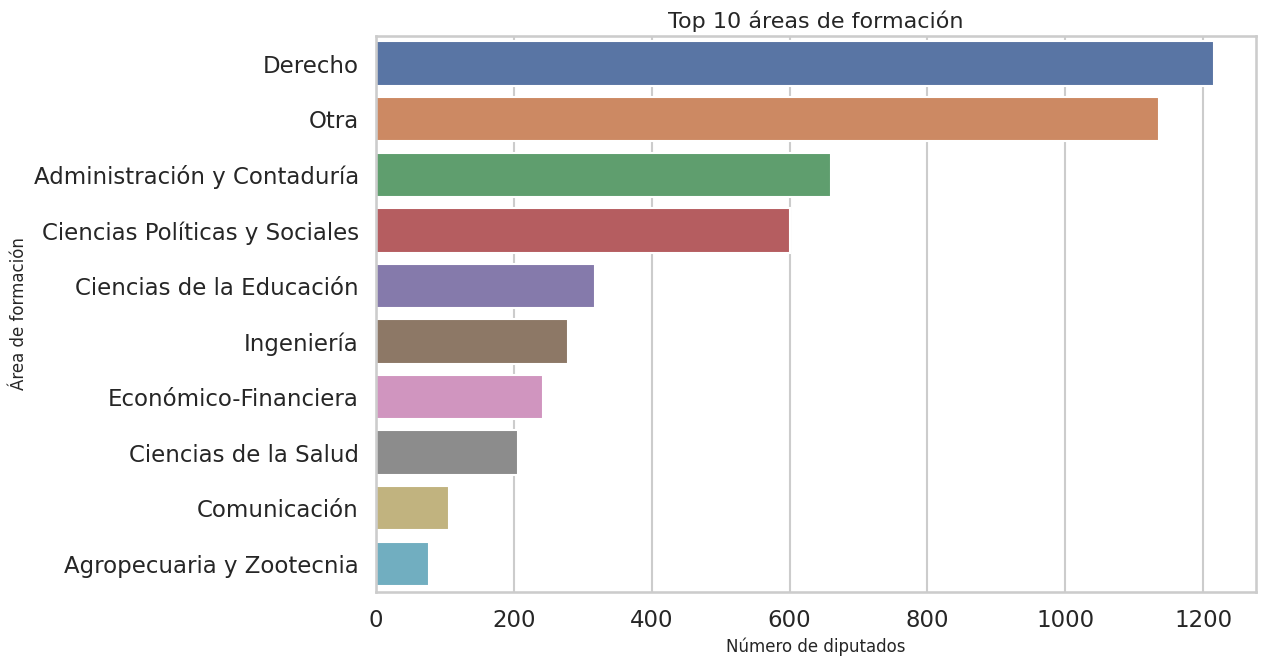

In [10]:
area_top = (
    df['area_formacion']
    .fillna('Desconocido')
    .value_counts()
    .head(10)
    .rename_axis('area_formacion')
    .reset_index(name='n')
)
area_top['pct'] = 100 * area_top['n'] / len(df)

display(area_top)

fig, ax = plt.subplots(figsize=(13, 7))
sns.barplot(data=area_top, x='n', y='area_formacion', hue='area_formacion', dodge=False, ax=ax, legend=False)
ax.set_title('Top 10 áreas de formación')
ax.set_xlabel('Número de diputados')
ax.set_ylabel('Área de formación')
plt.tight_layout()
plt.show()


,tipo,n,pct
0,Pública,2191,43.82
1,Privada,1116,22.32
2,Extranjera,406,8.12
3,Sin universidad identificada,2090,41.80


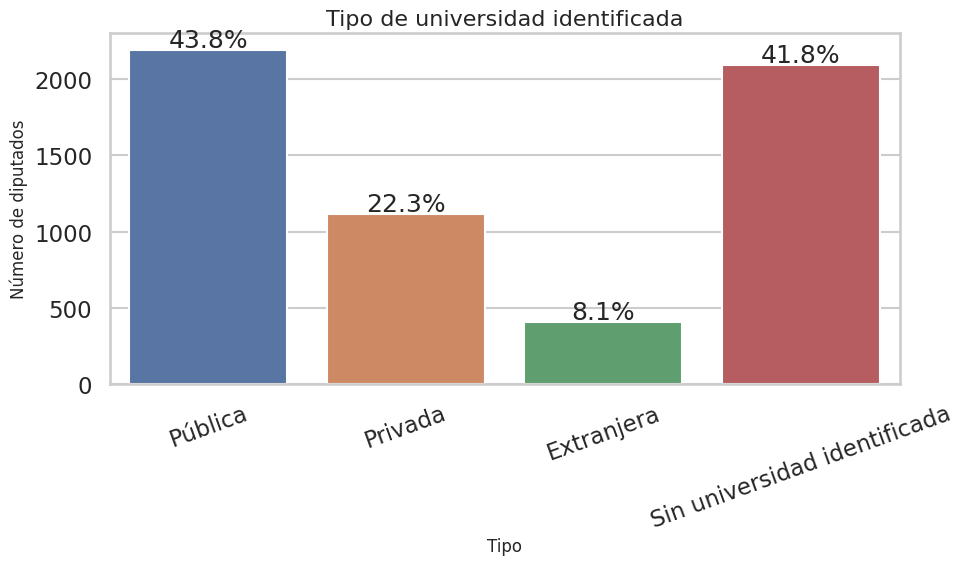

In [11]:
university_type = pd.DataFrame({
    'tipo': ['Pública', 'Privada', 'Extranjera', 'Sin universidad identificada'],
    'n': [
        int(df['univ_publica'].sum()),
        int(df['univ_privada'].sum()),
        int(df['univ_extranjera'].sum()),
        int((1 - df[['univ_publica', 'univ_privada', 'univ_extranjera']].max(axis=1)).sum()),
    ],
})
university_type['pct'] = 100 * university_type['n'] / len(df)

display(university_type)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=university_type, x='tipo', y='n', hue='tipo', dodge=False, ax=ax, legend=False)
ax.set_title('Tipo de universidad identificada')
ax.set_xlabel('Tipo')
ax.set_ylabel('Número de diputados')
ax.tick_params(axis='x', rotation=20)
for i, row in university_type.reset_index(drop=True).iterrows():
    ax.text(i, row['n'] + 20, f"{row['pct']:.1f}%", ha='center')
plt.tight_layout()
plt.show()


,partido,promedio,n
6,PANAL,4.250000,40
13,PT,4.089947,189
4,MORENA,3.986979,768
3,MC,3.975000,120
14,PVEM,3.643137,255
11,PRI,3.586957,1564
5,PAN,3.550847,1298
10,PRD,3.436909,634
2,INDEPENDIENTE,2.106383,47


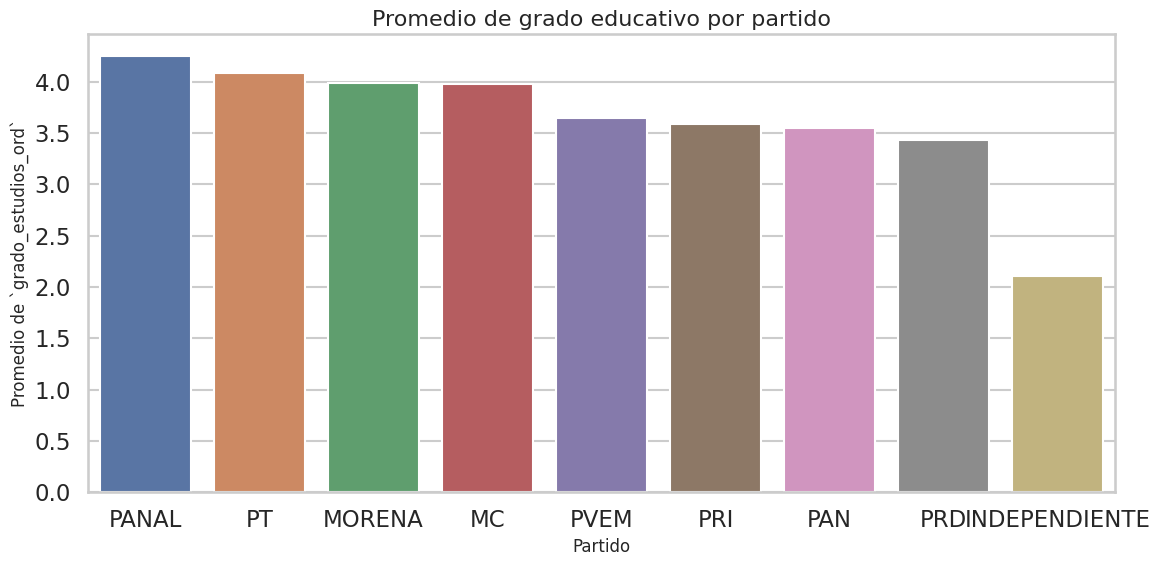

In [12]:
edu_by_party = (
    df.groupby('partido')['grado_estudios_ord']
    .agg(promedio='mean', n='size')
    .reset_index()
    .sort_values('promedio', ascending=False)
)
edu_by_party = edu_by_party[edu_by_party['n'] >= 40]

display(edu_by_party)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=edu_by_party, x='partido', y='promedio', hue='partido', dodge=False, ax=ax, legend=False)
ax.set_title('Promedio de grado educativo por partido')
ax.set_xlabel('Partido')
ax.set_ylabel('Promedio de `grado_estudios_ord`')
plt.tight_layout()
plt.show()


## 5. Perfil de edad

,edad_al_tomar_cargo
count,4490.000000
mean,46.202227
std,10.443415
min,21.000000
25%,39.000000
50%,46.000000
75%,53.000000
max,85.000000


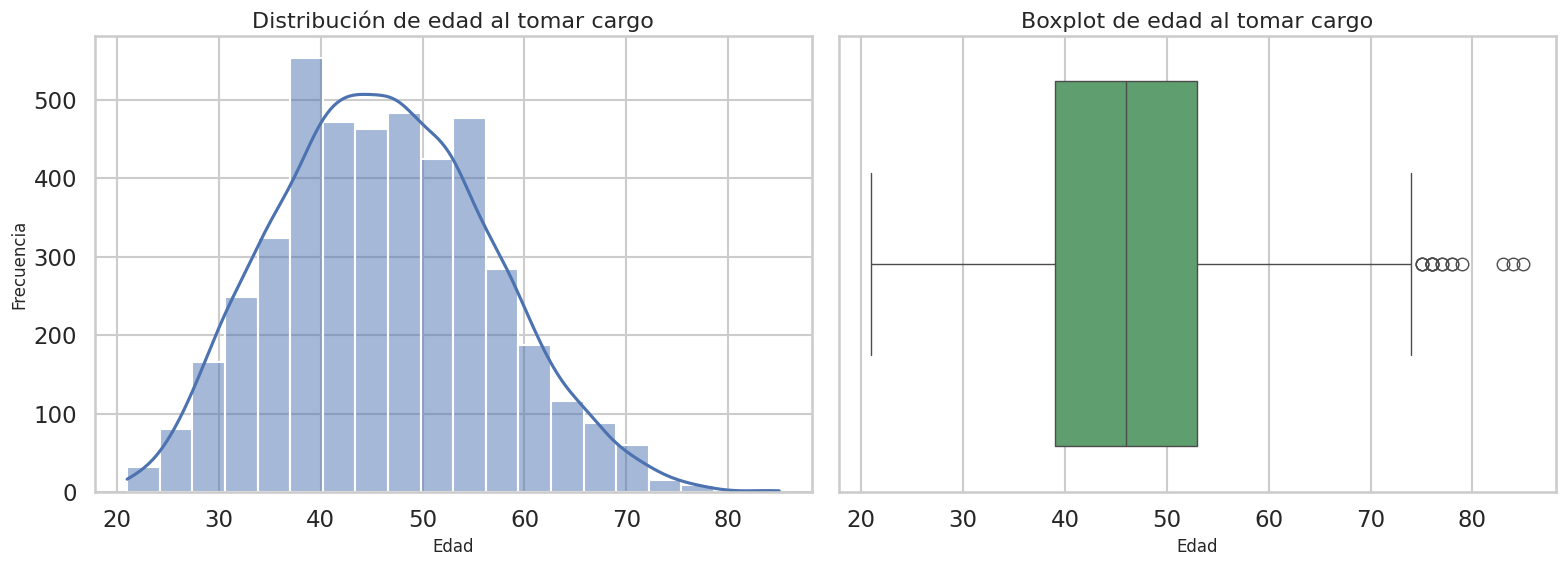

In [13]:
age_series = df['edad_al_tomar_cargo'].dropna()
display(age_series.describe().to_frame(name='edad_al_tomar_cargo'))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.histplot(age_series, bins=20, kde=True, ax=axes[0], color='#4C72B0')
axes[0].set_title('Distribución de edad al tomar cargo')
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Frecuencia')

sns.boxplot(x=age_series, ax=axes[1], color='#55A868')
axes[1].set_title('Boxplot de edad al tomar cargo')
axes[1].set_xlabel('Edad')

plt.tight_layout()
plt.show()


,legislatura_num,legislatura_roman,edad_al_tomar_cargo
0,57,LVII,45.834606
1,58,LVIII,44.217573
2,59,LIX,44.575053
3,60,LX,44.882591
4,61,LXI,46.022634
5,62,LXII,46.421634
6,63,LXIII,46.013889
7,64,LXIV,48.290155
8,65,LXV,47.664544
9,66,LXVI,48.370968


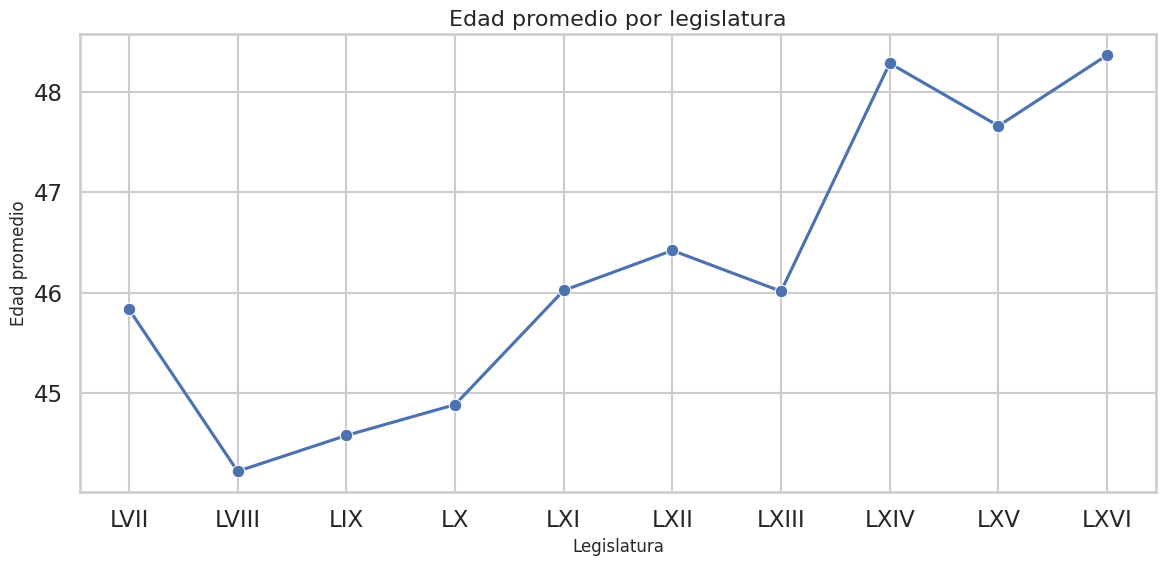

In [14]:
avg_age_leg = (
    plot_df.groupby(['legislatura_num', 'legislatura_roman'])['edad_al_tomar_cargo']
    .mean()
    .reset_index()
    .sort_values('legislatura_num')
)

display(avg_age_leg)

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=avg_age_leg, x='legislatura_roman', y='edad_al_tomar_cargo', marker='o', ax=ax)
ax.set_title('Edad promedio por legislatura')
ax.set_xlabel('Legislatura')
ax.set_ylabel('Edad promedio')
plt.tight_layout()
plt.show()


## 6. Experiencia legislativa previa

,n_cargos_legislativos_prev,n,pct
0,0,2977,59.54
1,1,1453,29.06
2,2,500,10.00
3,3,70,1.40


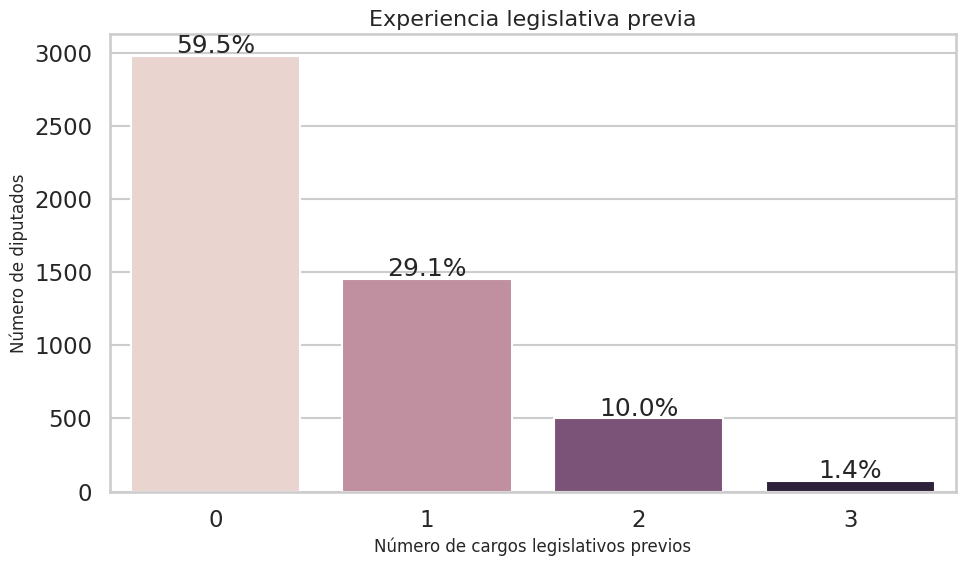

In [15]:
exp_dist = (
    df['n_cargos_legislativos_prev']
    .fillna(0)
    .astype(int)
    .value_counts()
    .sort_index()
    .rename_axis('n_cargos_legislativos_prev')
    .reset_index(name='n')
)
exp_dist['pct'] = 100 * exp_dist['n'] / len(df)

display(exp_dist)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=exp_dist, x='n_cargos_legislativos_prev', y='n', hue='n_cargos_legislativos_prev', dodge=False, ax=ax, legend=False)
ax.set_title('Experiencia legislativa previa')
ax.set_xlabel('Número de cargos legislativos previos')
ax.set_ylabel('Número de diputados')
for i, row in exp_dist.reset_index(drop=True).iterrows():
    ax.text(i, row['n'] + 20, f"{row['pct']:.1f}%", ha='center')
plt.tight_layout()
plt.show()


,n_cargos_legislativos_prev,n,promedio_comisiones,promedio_trayectoria_politica
0,0,2977,3.914007,4.927108
1,1,1453,4.071576,6.960771
2,2,500,4.002000,9.840000
3,3,70,4.000000,12.942857


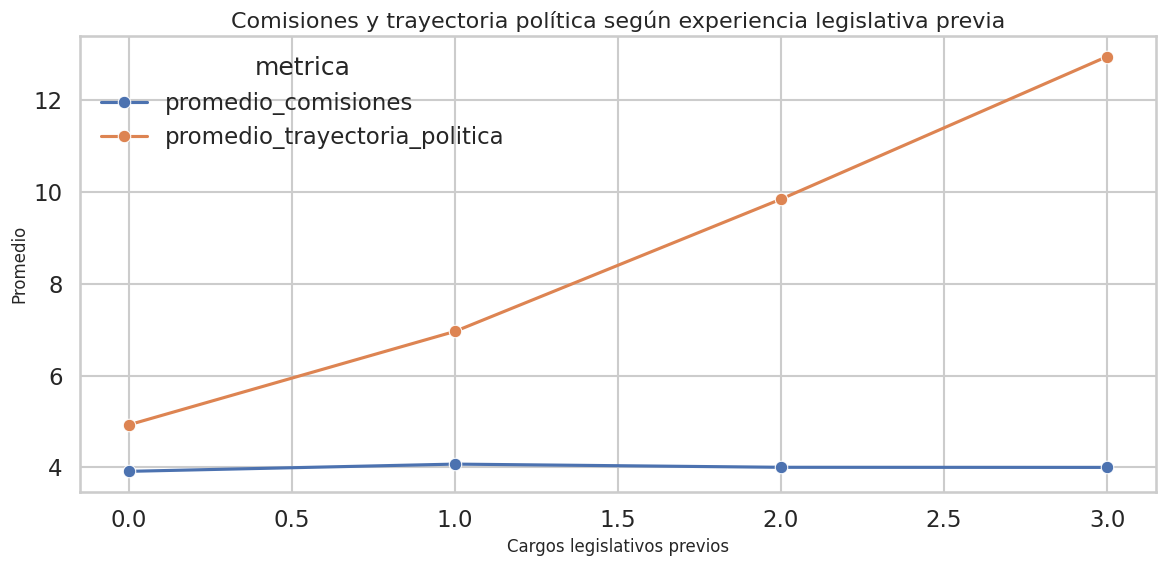

In [16]:
experience_summary = (
    df.groupby('n_cargos_legislativos_prev')
    .agg(
        n=('diputado_id', 'size'),
        promedio_comisiones=('n_comisiones', 'mean'),
        promedio_trayectoria_politica=('n_trayectoria_politica', 'mean'),
    )
    .reset_index()
    .sort_values('n_cargos_legislativos_prev')
)

display(experience_summary)

melted = experience_summary.melt(
    id_vars='n_cargos_legislativos_prev',
    value_vars=['promedio_comisiones', 'promedio_trayectoria_politica'],
    var_name='metrica',
    value_name='valor',
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=melted, x='n_cargos_legislativos_prev', y='valor', hue='metrica', marker='o', ax=ax)
ax.set_title('Comisiones y trayectoria política según experiencia legislativa previa')
ax.set_xlabel('Cargos legislativos previos')
ax.set_ylabel('Promedio')
plt.tight_layout()
plt.show()


## 7. Trayectorias por legislatura

,legislatura_num,legislatura_roman,n_trayectoria_admin,n_trayectoria_politica,n_trayectoria_legislativa,n_trayectoria_empresarial
0,57,LVII,2.778,6.992,0.622,1.402
1,58,LVIII,2.628,6.748,0.684,1.654
2,59,LIX,3.466,8.400,0.732,1.654
3,60,LX,3.140,6.588,0.752,2.132
4,61,LXI,3.996,7.586,0.848,1.900
5,62,LXII,3.420,6.052,0.802,1.676
6,63,LXIII,3.698,5.872,0.858,1.582
7,64,LXIV,2.620,4.314,0.616,1.544
8,65,LXV,2.848,4.184,0.974,1.400
9,66,LXVI,3.060,4.480,1.148,1.394


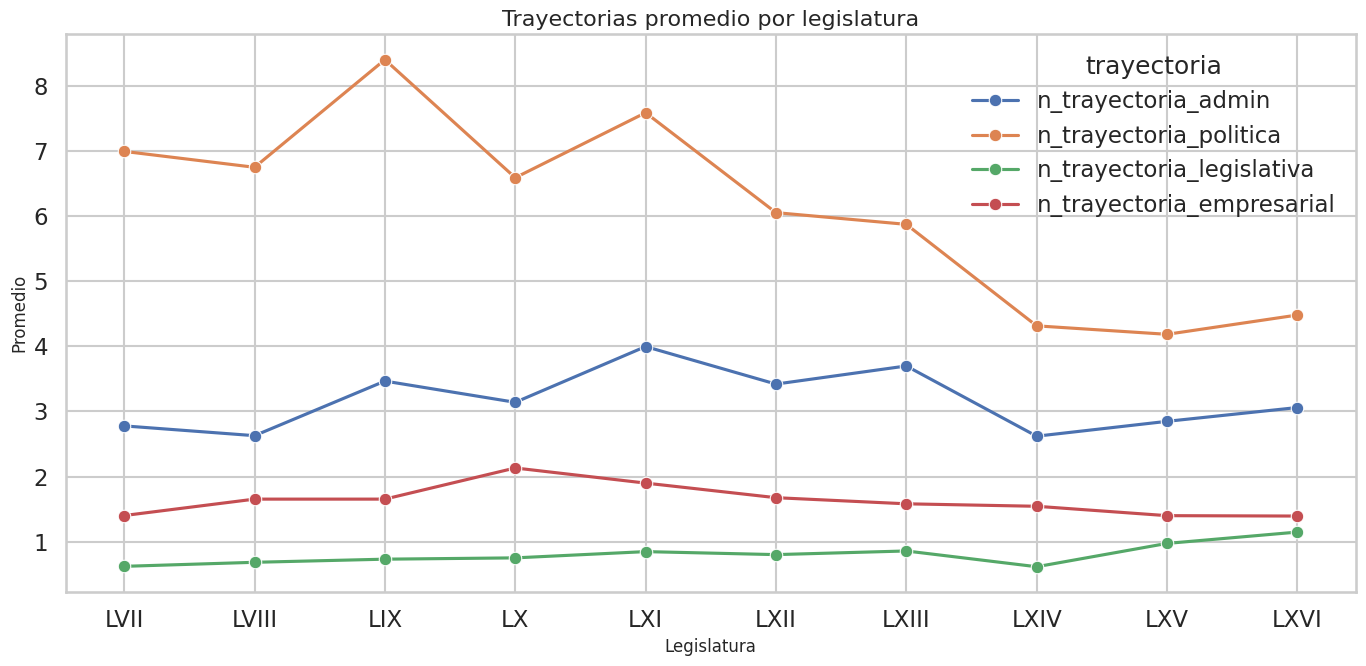

In [17]:
trajectory_by_leg = (
    plot_df.groupby(['legislatura_num', 'legislatura_roman'])[
        ['n_trayectoria_admin', 'n_trayectoria_politica', 'n_trayectoria_legislativa', 'n_trayectoria_empresarial']
    ]
    .mean()
    .reset_index()
    .sort_values('legislatura_num')
)

display(trajectory_by_leg)

traj_long = trajectory_by_leg.melt(
    id_vars=['legislatura_num', 'legislatura_roman'],
    value_vars=['n_trayectoria_admin', 'n_trayectoria_politica', 'n_trayectoria_legislativa', 'n_trayectoria_empresarial'],
    var_name='trayectoria',
    value_name='promedio',
)

fig, ax = plt.subplots(figsize=(14, 7))
sns.lineplot(data=traj_long, x='legislatura_roman', y='promedio', hue='trayectoria', marker='o', ax=ax)
ax.set_title('Trayectorias promedio por legislatura')
ax.set_xlabel('Legislatura')
ax.set_ylabel('Promedio')
plt.tight_layout()
plt.show()


## 8. Comisiones

In [18]:
commission_summary = pd.DataFrame({
    'indicador': [
        'Promedio comisiones',
        'Promedio comisiones especiales',
        '% preside >=1 comisión',
        '% líder de comisión',
        'Total presidencias',
        'Total liderazgos',
    ],
    'valor': [
        df['n_comisiones'].mean(),
        df['n_comisiones_especiales'].mean(),
        100 * (df['n_presidencias'] >= 1).mean(),
        100 * df['lider_comision'].mean(),
        df['n_presidencias'].sum(),
        df['lider_comision'].sum(),
    ],
})

display(commission_summary)


,indicador,valor
0,Promedio comisiones,3.9698
1,Promedio comisiones especiales,0.3920
2,% preside >=1 comisión,17.2600
3,% líder de comisión,81.8600
4,Total presidencias,916.0000
5,Total liderazgos,4093.0000


,partido,n_comisiones_nodales,n_comisiones_tematicas,n_comisiones_lastre,n_presidencias,total_comisiones_tipo
15,SIN PARTIDO,1.352941,1.882353,0.764706,0.117647,4.000000
4,MORENA,0.878906,2.186198,0.692708,0.141927,3.757812
14,PVEM,0.898039,2.090196,0.580392,0.211765,3.568627
9,PES,0.617647,2.000000,0.735294,0.294118,3.352941
13,PT,0.841270,1.894180,0.534392,0.158730,3.269841
3,MC,0.716667,1.866667,0.591667,0.175000,3.175000
6,PANAL,0.650000,2.050000,0.375000,0.225000,3.075000
1,CONVERGENCIA,0.956522,1.521739,0.565217,0.260870,3.043478


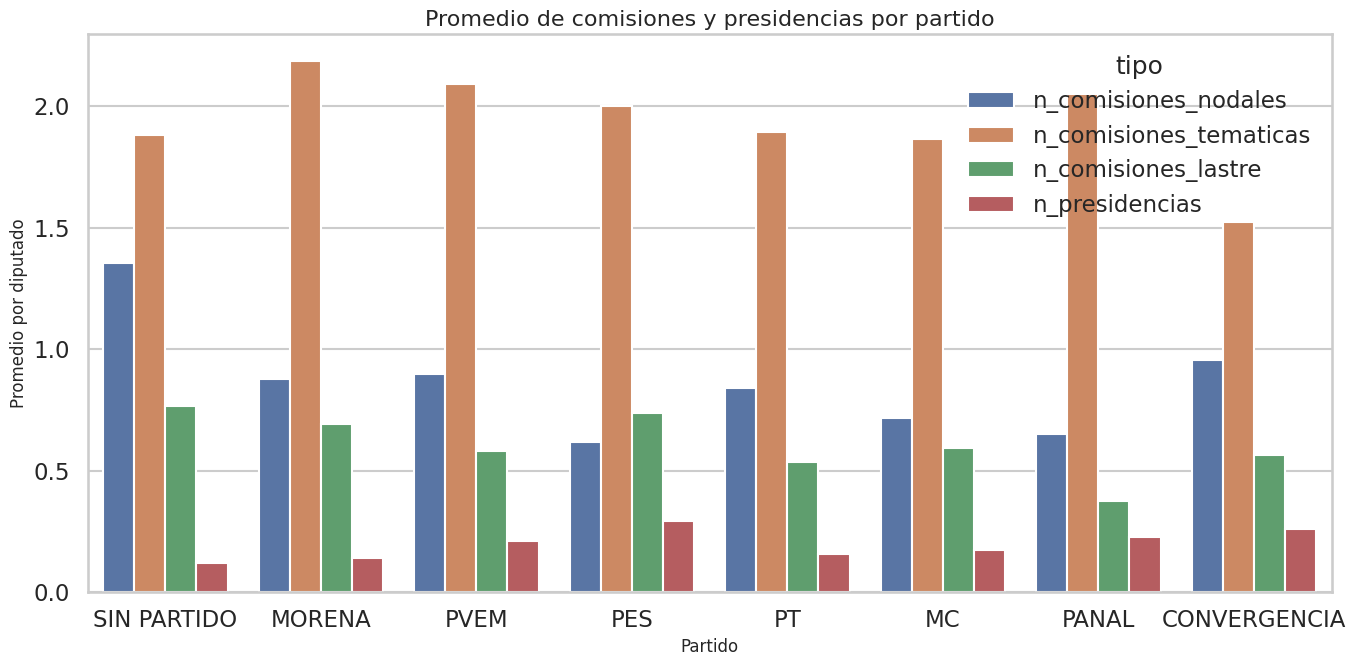

In [19]:
by_party = (
    df.groupby('partido')[['n_comisiones_nodales', 'n_comisiones_tematicas', 'n_comisiones_lastre', 'n_presidencias']]
    .mean()
    .reset_index()
)
by_party['total_comisiones_tipo'] = (
    by_party['n_comisiones_nodales'] + by_party['n_comisiones_tematicas'] + by_party['n_comisiones_lastre']
)
by_party = by_party.sort_values('total_comisiones_tipo', ascending=False).head(8)

display(by_party)

party_long = by_party.melt(
    id_vars='partido',
    value_vars=['n_comisiones_nodales', 'n_comisiones_tematicas', 'n_comisiones_lastre', 'n_presidencias'],
    var_name='tipo',
    value_name='promedio',
)

fig, ax = plt.subplots(figsize=(14, 7))
sns.barplot(data=party_long, x='partido', y='promedio', hue='tipo', ax=ax)
ax.set_title('Promedio de comisiones y presidencias por partido')
ax.set_xlabel('Partido')
ax.set_ylabel('Promedio por diputado')
plt.tight_layout()
plt.show()


## 9. Correlaciones con número de comisiones

,n_comisiones,n_trayectoria_admin,n_trayectoria_politica,nivel_cargo_max,n_trayectoria_empresarial,n_cargos_legislativos_prev,edad_al_tomar_cargo
n_comisiones,1.000000,0.088093,0.067267,0.065957,0.041513,0.029831,-0.072372
n_trayectoria_admin,0.088093,1.000000,0.190400,0.625892,-0.033564,0.161859,0.217274
n_trayectoria_politica,0.067267,0.190400,1.000000,0.151435,-0.010100,0.329561,0.126886
nivel_cargo_max,0.065957,0.625892,0.151435,1.000000,-0.024152,0.189990,0.134259
n_trayectoria_empresarial,0.041513,-0.033564,-0.010100,-0.024152,1.000000,-0.011953,0.096638
n_cargos_legislativos_prev,0.029831,0.161859,0.329561,0.189990,-0.011953,1.000000,0.269761
edad_al_tomar_cargo,-0.072372,0.217274,0.126886,0.134259,0.096638,0.269761,1.000000


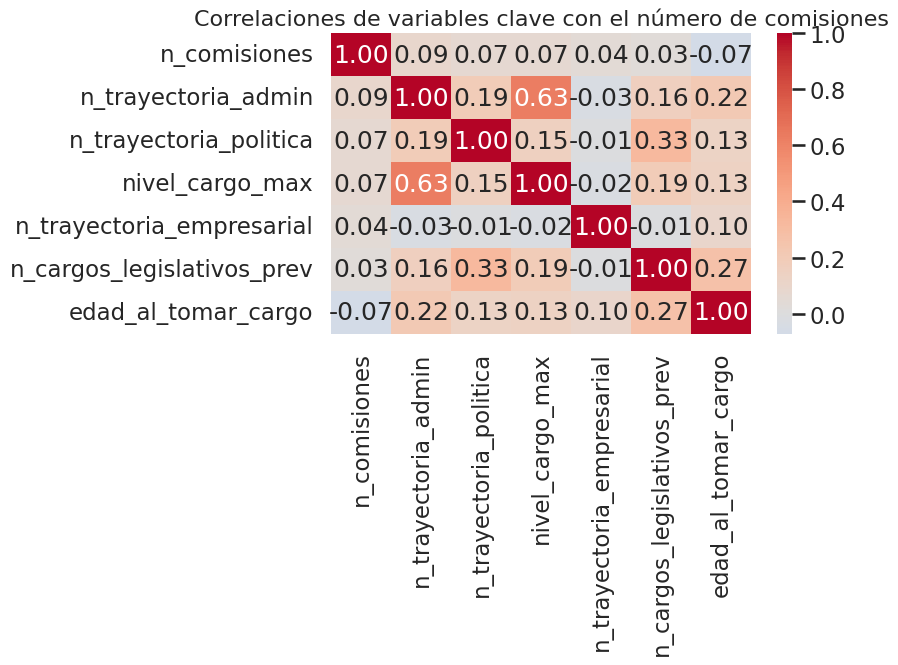

In [20]:
corr_cols = [
    'n_comisiones',
    'n_trayectoria_admin',
    'n_trayectoria_politica',
    'nivel_cargo_max',
    'n_trayectoria_empresarial',
    'n_cargos_legislativos_prev',
    'edad_al_tomar_cargo',
]

corr = df[corr_cols].corr(numeric_only=True)
display(corr)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', ax=ax)
ax.set_title('Correlaciones de variables clave con el número de comisiones')
plt.tight_layout()
plt.show()


## Notas

- El notebook usa la fuente parquet referida por el reporte, así que las gráficas se actualizan si cambia el archivo base.
- Varias tablas del reporte se reconstruyen desde columnas crudas en vez de parsear el markdown.
- El reporte menciona `da_report_20260421.md`, pero el archivo equivalente presente en este repositorio es `reports/eda/eda_report_20260421.md`.
